In [1]:
from lib import epl 
from lib import OSN
from lib import readout
from lib import plots
import numpy as np
import pickle 
import brian2 as b2
import brian2hears as b2h
import matplotlib.pyplot as plt
from preprocess import preprocessing as pre
import os.path
from os import path
%matplotlib inline

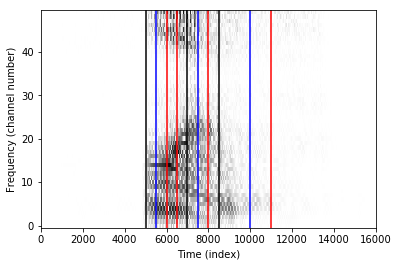

In [2]:
trainingSounds = ["0a196374_nohash_1"]
trainingSpect = pre.spectArray(trainingSounds[0], cfN=50)

pre.spectShow(trainingSpect[:,5000:7000]) #, zoom_x=5000, zoom_y=7000)

trainingIndex = [6000]
testingIndex = [ 6000, 5000, 5500, 6500, 7000,7500, 8000, 8500, 10000, 11000]
scale = 15 #changed because we're normalising in a different way
#I changed scale from 15 to 10 because 16 resulted in a KeyError: 21
# normalising 0 to 1, then multiply by scale (15)
# this is to scale each individual sample
range_f = 20  #changed from 100 to 10
step_f = 10
#sample the odors

colors = ['r','k','b','r','k','b','r','k','b','r']
pre.spectShow(trainingSpect)
for xc,c in zip(testingIndex,colors):
    plt.axvline(x=xc, label='line at x = {}'.format(xc), c=c)
plt.show()

trainingOdors = pre.chooseSound(trainingSpect, range_f, step_f, trainingIndex[0], scale)
for i in testingIndex:
    if i == testingIndex[0]:
        testOdors = pre.chooseSound(trainingSpect, range_f, step_f, i, scale)
    else:
        testOdors = np.concatenate((testOdors,pre.chooseSound(trainingSpect, range_f, step_f, i, scale)))


In [3]:
from lib import epl 


nOdors = len(trainingOdors); 
nTestPerOdor = len(testOdors)/nOdors;  
print("Number of odors to train = " + str(len(trainingOdors))); 
print("Number of odors to test = " + str(len(testOdors))); 

#Network initialization
nMCs = len(trainingOdors[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 




#Training
for i in range(0, len(trainingOdors)):
    print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1, nGammaPerOdor = 5);  #default value is 5, may experiment with 10
    epl.GClayer.invokeNeurogenesis();
    sniff(trainingOdors[i], learn_flag=0);

#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0); 
    if(i==len(testOdors)-1):
        print(str(i+1) + " odors tested"); 

#Readout
sMatrix = readout.readout(epl.gammaCode, nOdors, nTestPerOdor)  
#print out sMatrix (in readout library)
#Plots
plots.plotFigure3b(epl.gammaCode); 



Number of odors to train = 1
Number of odors to test = 10
Training odor 1


KeyboardInterrupt: 

In [ ]:
plots.plotFigure3d(sMatrix); 

In [ ]:
pre.plotTrainedtoTarget(sMatrix)

In [ ]:
trainingSim = pre.perturb(trainingOdors)

In [ ]:
pre.generatePerturbedTest(trainingSim)

In [ ]:
change_ndx = np.random.randint(0,trainingSim.shape[0], int(trainingSim.shape[0]*perRand))


In [ ]:
trainingSim[change_ndx] = np.random.randint(0,15, change_ndx.shape[0] )
trainingSim